# Quantum Kernel vs Classical Kernel for Potential Energy Surface (PES) Prediction

This notebook demonstrates how to predict the Potential Energy Surface (PES) of a Lithium Hydride (LiH) molecule using both Classical (RBF, NNGP) and Quantum Kernels (Fixed Ansatz, Learned Ansatz (Variable Ansatz), VQE Ansatz). We evaluate the models on two tasks: **Interpolation** (predicting intermediate bond lengths) and **Extrapolation** (predicting outer bond lengths).

## 1. Imports & Configuration

Import necessary libraries and define global constants, such as color maps and the specific random seed used for reproducibility.

In [1]:
# Install required packages
# %pip install qiskit qiskit-aer 'qiskit-nature[pyscf]' qiskit-algorithms
# %pip install pandas openpyxl matplotlib pylatexenc pyscf scikit-learn scipy

In [1]:
import os
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from typing import List, Callable, Dict
from dataclasses import dataclass
from scipy.optimize import minimize
from scipy.linalg import cho_solve
from sklearn.neural_network import MLPRegressor

import qiskit
import qiskit_aer
import qiskit_nature
import qiskit_algorithms
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.second_q.mappers import JordanWignerMapper
from qiskit_nature.second_q.transformers import ActiveSpaceTransformer
from qiskit_nature.second_q.circuit.library import HartreeFock, UCCSD

warnings.filterwarnings('ignore')

BASIS = 'sto-3g'
VQE_MAXITER = 3000
VQE_TOL = 1e-6
CHEMICAL_ACCURACY_CM = 349.755
SEED = 48

COLOR_MAP = {
    'RBF': '#E83C90',
    'VQE Ansatz Kernel': '#8D75B8',
    'Q Fixed': '#D96A1C',
    'Q Variable': '#1C9E7B',
    'NNGP Proxy': '#74AD2C'
}
FINAL_ORDER =['RBF', 'Q Fixed', 'Q Variable', 'NNGP Proxy', 'VQE Ansatz Kernel']

print(f"Qiskit version: {qiskit.__version__}")

Qiskit version: 2.3.1


## 2. Dataset Generation
We define classes to generate the LiH dataset.

In [2]:
# Coordinate Transformations
def transform_r_to_x(R: np.ndarray, a: float = 1.0) -> np.ndarray:
    return np.exp(-R / a)

def transform_x_to_r(X: np.ndarray, a: float = 1.0) -> np.ndarray:
    return -a * np.log(np.maximum(X, 1e-9))

class LiHActiveSpaceCache:
    def __init__(self, r_min=0.5, r_max=3.5, num=30, basis=BASIS):
        self.r_grid = np.linspace(r_min, r_max, num).astype(float)
        self.basis = basis
        self.mapper = JordanWignerMapper()
        self.n_electrons = 2
        self.n_spatial_orbitals = 2
        self.data_points =[]
        self._build_all()

    def _build_all(self):
        print(f"Building LiH Dataset ({self.n_electrons}e, {self.n_spatial_orbitals} orbitals)...")
        for r in self.r_grid:
            try:
                driver = PySCFDriver(atom=f"Li 0 0 0; H 0 0 {r}", basis=self.basis)
                problem = driver.run()
                transformer = ActiveSpaceTransformer(num_electrons=self.n_electrons, num_spatial_orbitals=self.n_spatial_orbitals)
                problem = transformer.transform(problem)

                H2 = problem.hamiltonian.second_q_op()
                Hq = self.mapper.map(H2)
                H_mat = Hq.to_matrix()
                w, _ = np.linalg.eigh(H_mat)

                self.data_points.append({"R": r, "E_exact": w[0]})
            except Exception:
                pass
        print(f"Cache created with {len(self.data_points)} points.")

    def get_dataset(self):
        df = pd.DataFrame(self.data_points)
        if df.empty: raise ValueError("Dataset Empty.")
        R = df["R"].values
        E = df["E_exact"].values
        E0 = E.min()
        y_cm = (E - E0) * 219474.63 # Convert Hartree to cm^-1
        X = transform_r_to_x(R)
        return X.reshape(-1, 1), y_cm.astype(float), R.reshape(-1, 1), E0

class LiHDataset:
    def __init__(self, cache, a_transform=1.0, ha_to_cm=219474.63):
        self.cache = cache
        self.a = a_transform
        self.ha_to_cm = ha_to_cm

    def generate(self):
        return self.cache.get_dataset()

## 3. Data Splitting Methods
- **Interpolation:** Randomly splits the data, so the model predicts "gaps" between known points.  
- **Extrapolation:** Uses the central points for training and asks the model to predict the outer edges.

In [3]:
def interpolation_split(X, y, R, train_frac=0.5, seed=42):
    N = len(X)
    rng = np.random.RandomState(seed)
    indices = np.arange(N)
    rng.shuffle(indices)
    n_train = int(N * train_frac)
    train_idx, test_idx = np.sort(indices[:n_train]), np.sort(indices[n_train:])
    return X[train_idx], y[train_idx], R[train_idx], X[test_idx], y[test_idx], R[test_idx]

def extrapolation_split(X, y, R, center_frac=0.5):
    N = len(X)
    n_train = int(N * center_frac)
    start = (N - n_train) // 2
    train_idx = np.arange(start, start + n_train)
    test_idx = np.setdiff1d(np.arange(N), train_idx)
    return X[train_idx], y[train_idx], R[train_idx], X[test_idx], y[test_idx], R[test_idx]

## 4. VQE Proxy & DNN Regressor

This section defines the VQE setup to find optimal parameters ($\theta$) for the quantum states. A Deep Neural Network (DNN) is then trained to predict these parameters continuously across $R$, enabling the creation of the **VQE Ansatz Kernel**.

In [4]:
class VQEProxyLiH:
    def __init__(self, basis=BASIS):
        self.basis = basis
        self.mapper = JordanWignerMapper()
        self._ansatz_cache = {}

    def get_ansatz_and_ops(self, r: float):
        r_key = round(r, 4)
        if r_key in self._ansatz_cache: return self._ansatz_cache[r_key]

        driver = PySCFDriver(atom=f"Li 0 0 0; H 0 0 {r}", basis=self.basis)
        problem = transformer = ActiveSpaceTransformer(num_electrons=2, num_spatial_orbitals=2).transform(driver.run())
        H_op = self.mapper.map(problem.hamiltonian.second_q_op())

        init_state = HartreeFock(problem.num_spatial_orbitals, problem.num_particles, self.mapper)
        ansatz = UCCSD(problem.num_spatial_orbitals, problem.num_particles, self.mapper, initial_state=init_state)

        self._ansatz_cache[r_key] = (ansatz, H_op)
        return ansatz, H_op

    def run_vqe_optimization(self, r: float, initial_point=None):
        ansatz, H_op = self.get_ansatz_and_ops(r)
        def cost(params):
            if len(params) != ansatz.num_parameters: return 0.0
            qc = ansatz.assign_parameters(params)
            return Statevector(qc).expectation_value(H_op).real

        initial_point = initial_point if initial_point is not None else np.zeros(ansatz.num_parameters)
        res = minimize(cost, initial_point, method='L-BFGS-B', tol=VQE_TOL, options={'maxiter': VQE_MAXITER})
        return res.x

    def get_state_vector(self, r: float, theta: np.ndarray):
        ansatz, _ = self.get_ansatz_and_ops(r)
        qc = ansatz.assign_parameters(theta[:ansatz.num_parameters])
        return Statevector(qc).data

class VQEParamRegressor:
    def __init__(self, vqe_proxy, hidden_layer_sizes=(60, 60, 60), seed=42):
        self.vqe = vqe_proxy
        self.mlp = MLPRegressor(hidden_layer_sizes=hidden_layer_sizes, activation='tanh', solver='adam', max_iter=3000, random_state=seed)
        self.is_fitted = False

    def fit(self, X_train, R_train):
        sorted_idx = np.argsort(R_train.ravel())
        R_sorted, X_sorted = R_train.ravel()[sorted_idx], X_train[sorted_idx]
        theta_list, last_theta =[], None

        for r in R_sorted:
            try:
                theta_opt = self.vqe.run_vqe_optimization(r, initial_point=last_theta)
                last_theta = theta_opt
                theta_list.append(theta_opt)
            except Exception:
                if last_theta is not None: theta_list.append(last_theta)

        self.mlp.fit(X_sorted, np.array(theta_list))
        self.is_fitted = True

    def predict_theta(self, X):
        return self.mlp.predict(X)

class DNNVQEKernelGPR:
    def __init__(self, vqe_proxy, dnn_regressor, a_transform=1.0, jitter=1e-6):
        self.vqe, self.dnn, self.a, self.jitter = vqe_proxy, dnn_regressor, a_transform, jitter

    def fit(self, X_train, y_train):
        y_train = y_train.reshape(-1, 1)
        thetas = self.dnn.predict_theta(X_train)
        R = transform_x_to_r(X_train, self.a).ravel()

        self.train_states = np.array([self.vqe.get_state_vector(r, th) for r, th in zip(R, thetas)])
        F = np.abs(self.train_states @ self.train_states.conj().T)**2

        best_rmse, self.gamma = float('inf'), 1.0
        for g in[0.1, 0.25, 0.5, 1.0, 2.0, 5.0]:
            K = np.exp(-(1.0 - F) / g) + np.eye(len(F)) * self.jitter
            try:
                L = np.linalg.cholesky(K)
                alpha = cho_solve((L, True), y_train)
                rmse = np.sqrt(np.mean((y_train.ravel() - (K @ alpha).ravel())**2))
                if rmse < best_rmse:
                    best_rmse, self.gamma, self.L, self.alpha = rmse, g, L, alpha
            except: continue
        return self

    def predict(self, X_star):
        thetas = self.dnn.predict_theta(X_star)
        R = transform_x_to_r(X_star, self.a).ravel()
        test_states = np.array([self.vqe.get_state_vector(r, th) for r, th in zip(R, thetas)])
        F_star = np.abs(test_states @ self.train_states.conj().T)**2
        K_star = np.exp(-(1.0 - F_star) / self.gamma)
        return (K_star @ self.alpha).ravel()

    def rmse(self, y_true, y_pred):
        return np.sqrt(np.mean((y_true - y_pred)**2))

## 5. Kernels & Optimizers
Implementation of Gaussian Process Regressors with Classical RBF and basic Quantum Kernels. We also include a Random Search optimizer to tune the kernel hyperparameters.

In [5]:
class GPZeroNoise:
    def __init__(self, kernel_fn: Callable, jitter: float = 1e-6):
        self.kernel_fn, self.jitter = kernel_fn, jitter

    def fit(self, X, y, theta=None):
        self.X_train, self.y_train = np.asarray(X), np.asarray(y).reshape(-1, 1)
        theta = theta or {}
        K = self.kernel_fn(self.X_train, self.X_train, theta) + np.eye(len(X)) * self.jitter
        try:
            self.L = np.linalg.cholesky(K)
            self.alpha = cho_solve((self.L, True), self.y_train)
            return 0
        except: return -np.inf

    def predict(self, X_star, theta=None):
        K_star = self.kernel_fn(self.X_train, X_star, theta or {})
        return (K_star.T @ self.alpha).ravel()

    def rmse(self, y_true, y_pred):
        return np.sqrt(np.mean((y_true - y_pred)**2))

class GPRWithNoise(GPZeroNoise):
    def __init__(self, kernel_fn, noise_level=1e-5):
        super().__init__(kernel_fn)
        self.noise_level = noise_level

    def fit(self, X, y, theta=None):
        self.X_train, self.y_train = np.asarray(X), np.asarray(y).reshape(-1, 1)
        K = self.kernel_fn(self.X_train, self.X_train, theta or {}) + np.eye(len(X)) * (self.noise_level + self.jitter)
        try:
            self.L = np.linalg.cholesky(K)
            self.alpha = cho_solve((self.L, True), self.y_train)
            return 0
        except: return -np.inf

class ClassicalRBFKernel:
    def __call__(self, X, Z, theta):
        ell = theta.get("ell", 1.0)
        d = np.sum(X**2, 1)[:, None] + np.sum(Z**2, 1) - 2 * X @ Z.T
        return np.exp(-0.5 * d / (ell**2))

class QuantumKernelFixedAnsatz:
    def __init__(self, m=2): self.m = m
    def _state(self, x, theta):
        qc = QuantumCircuit(self.m)
        qc.h(range(self.m))
        qc.rzz(theta.get("theta_rzz", 1.0), 0, 1)
        qc.ry(x[0] / theta.get("theta_ry", 1.0), 0)
        return Statevector(qc).data
    def __call__(self, X, Z, theta):
        sx, sz =[self._state(x, theta) for x in X], [self._state(z, theta) for z in Z]
        return np.abs(np.array(sx) @ np.array(sz).conj().T)**2

@dataclass
class CircuitStructure: m: int; layers: List[bool]

class QuantumKernelAnsatz:
    def __init__(self, struct): self.struct, self.m = struct, struct.m
    def _state(self, x, theta):
        qc = QuantumCircuit(self.m)
        qc.h(range(self.m))
        for flag in self.struct.layers:
            if flag: qc.rzz(np.exp(-x[0]/theta.get("Theta_rzz", 1.0)), 0, 1)
        qc.ry(x[0] / theta.get("theta_ry", 1.0), 0)
        return Statevector(qc).data
    def __call__(self, X, Z, theta):
        sx, sz =[self._state(x, theta) for x in X], [self._state(z, theta) for z in Z]
        return np.abs(np.array(sx) @ np.array(sz).conj().T)**2

class RandomSearch:
    def __init__(self, bounds, n_iter=15): self.bounds, self.n_iter = np.array(bounds), n_iter
    def maximize(self, func):
        bx, by = None, -np.inf
        for _ in range(self.n_iter):
            c = np.random.uniform(self.bounds[:,0], self.bounds[:,1])
            try:
                v, by, bx = func(c), max(by, func(c)), c if func(c) > by else bx
            except: pass
        return bx, by

class CompositionSearch:
    def __init__(self, m): self.m = m
    def search(self, X, y, b):
        s = CircuitStructure(self.m, [True, True])
        xb, _ = RandomSearch(b, n_iter=10).maximize(lambda v: GPZeroNoise(QuantumKernelAnsatz(s)).fit(X, y, {"theta_ry": v[0], "Theta_rzz": v[1]}))
        return s, {"theta_ry": xb[0] if xb is not None else 1.0, "Theta_rzz": xb[1] if xb is not None else 1.0}

## 6. Visualization & Main Loop
**English:**  
Here we define the function to plot the energy surface and RMSE bar charts. The `run_scenario` function trains all models on either the Interpolation or Extrapolation split.

In [6]:
def plot_results(results, R_train, y_train, R_test, y_test, R_full, scenario):
    os.makedirs('results', exist_ok=True)

    # --- Line Plot ---
    plt.figure(figsize=(10, 6))
    plt.scatter(R_train, y_train, s=90, color='blue', edgecolor='white', label='Train', zorder=5)
    plt.scatter(R_test, y_test, s=120, marker='x', color='red', linewidth=2, label='Test', zorder=6)

    for name in FINAL_ORDER:
        if name in results:
            plt.plot(R_full, results[name]['y_pred'], label=name, color=COLOR_MAP[name], linewidth=2.5)

    plt.xlabel("R (Å)", fontsize=18)
    plt.ylabel("Energy (cm⁻¹)", fontsize=18)
    plt.title(f"{scenario} Task (Seed: {SEED})", fontsize=20)
    plt.legend(fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"results/pes_{scenario.lower()}.png", dpi=300)
    plt.show()

    # --- Bar Plot ---
    plt.figure(figsize=(8, 5))
    methods = [k for k in FINAL_ORDER if k in results]
    rmses = [results[k]['rmse'] for k in methods]

    plt.bar(methods, rmses, color=[COLOR_MAP[k] for k in methods], alpha=0.8)
    plt.axhline(CHEMICAL_ACCURACY_CM, color='red', linestyle='--', label='Chemical Accuracy')
    plt.ylabel("RMSE (cm⁻¹)", fontsize=16)
    plt.title(f"Test RMSE for {scenario}", fontsize=18)
    plt.xticks(fontsize=12, rotation=20)
    plt.legend(fontsize=14)
    plt.tight_layout()
    plt.savefig(f"results/bar_{scenario.lower()}.png", dpi=300)
    plt.show()

def run_scenario(scenario_name, X, y, R):
    print(f"\n{'='*50}\n SCENARIO: {scenario_name}\n{'='*50}")
    np.random.seed(SEED) # Ensuring reproducibility for the single trial

    # Data Split
    if scenario_name == "Interpolation":
        Xt, yt, Rt, Xte, yte, Rte = interpolation_split(X, y, R, seed=SEED)
    else:
        Xt, yt, Rt, Xte, yte, Rte = extrapolation_split(X, y, R)

    R_full = np.linspace(R.min(), R.max(), 100).reshape(-1, 1)
    X_full = transform_r_to_x(R_full)
    results = {}

    # --- RBF ---
    rbf = ClassicalRBFKernel()
    xb_rbf, _ = RandomSearch([(0.1, 4.0)]).maximize(lambda v: GPZeroNoise(rbf).fit(Xt, yt, {"ell": v[0]}))
    ell = xb_rbf[0] if xb_rbf is not None else 1.0
    gp_rbf = GPZeroNoise(rbf)
    gp_rbf.fit(Xt, yt, {"ell": ell})
    results['RBF'] = {'rmse': gp_rbf.rmse(yte, gp_rbf.predict(Xte, {"ell": ell})),
                      'y_pred': gp_rbf.predict(X_full, {"ell": ell})}

    # --- Q Fixed ---
    kf = QuantumKernelFixedAnsatz()
    xb_qf, _ = RandomSearch([(0.1, 5.0), (0.1, 6.0)]).maximize(lambda v: GPZeroNoise(kf).fit(Xt, yt, {"theta_ry": v[0], "theta_rzz": v[1]}))
    th_qf = {"theta_ry": xb_qf[0], "theta_rzz": xb_qf[1]} if xb_qf is not None else {"theta_ry": 1.0, "theta_rzz": 1.0}
    gp_qf = GPZeroNoise(kf)
    gp_qf.fit(Xt, yt, th_qf)
    results['Q Fixed'] = {'rmse': gp_qf.rmse(yte, gp_qf.predict(Xte, th_qf)),
                          'y_pred': gp_qf.predict(X_full, th_qf)}

    # --- Q Variable ---
    s_vq, th_vq = CompositionSearch(2).search(Xt, yt,[(0.1, 5.0), (0.1, 5.0)])
    gp_vq = GPZeroNoise(QuantumKernelAnsatz(s_vq))
    gp_vq.fit(Xt, yt, th_vq)
    results['Q Variable'] = {'rmse': gp_vq.rmse(yte, gp_vq.predict(Xte, th_vq)),
                             'y_pred': gp_vq.predict(X_full, th_vq)}

    # --- NNGP Proxy ---
    gp_nngp = GPRWithNoise(rbf)
    gp_nngp.fit(Xt, yt, {"ell": ell})
    results['NNGP Proxy'] = {'rmse': gp_nngp.rmse(yte, gp_nngp.predict(Xte, {"ell": ell})),
                             'y_pred': gp_nngp.predict(X_full, {"ell": ell})}

    # --- VQE Ansatz Kernel ---
    print("Training DNN and optimizing VQE Proxy (This may take a minute)...")
    vqe_proxy = VQEProxyLiH()
    dnn = VQEParamRegressor(vqe_proxy, seed=SEED)
    dnn.fit(Xt, Rt)
    vqe_gp = DNNVQEKernelGPR(vqe_proxy, dnn)
    vqe_gp.fit(Xt, yt)
    results['VQE Ansatz Kernel'] = {'rmse': vqe_gp.rmse(yte, vqe_gp.predict(Xte)),
                                    'y_pred': vqe_gp.predict(X_full)}

    print(f"Results for {scenario_name}:")
    for k, v in results.items():
        print(f" - {k} RMSE: {v['rmse']:.2f} cm-1")

    plot_results(results, Rt, yt, Rte, yte, R_full, scenario_name)

## 7. Run the Evaluation
We first prepare the data, and then execute both Interpolation and Extrapolation tasks.

In [7]:
# Create dataset
cache = LiHActiveSpaceCache(num=30)
X, y, R, E0 = LiHDataset(cache).generate()

Building LiH Dataset (2e, 2 orbitals)...
Cache created with 30 points.


1. Run Interpolation


 SCENARIO: Interpolation
Training DNN and optimizing VQE Proxy (This may take a minute)...
Results for Interpolation:
 - RBF RMSE: 1450.05 cm-1
 - Q Fixed RMSE: 2563.60 cm-1
 - Q Variable RMSE: 1087.88 cm-1
 - NNGP Proxy RMSE: 1104.02 cm-1
 - VQE Ansatz Kernel RMSE: 892.50 cm-1


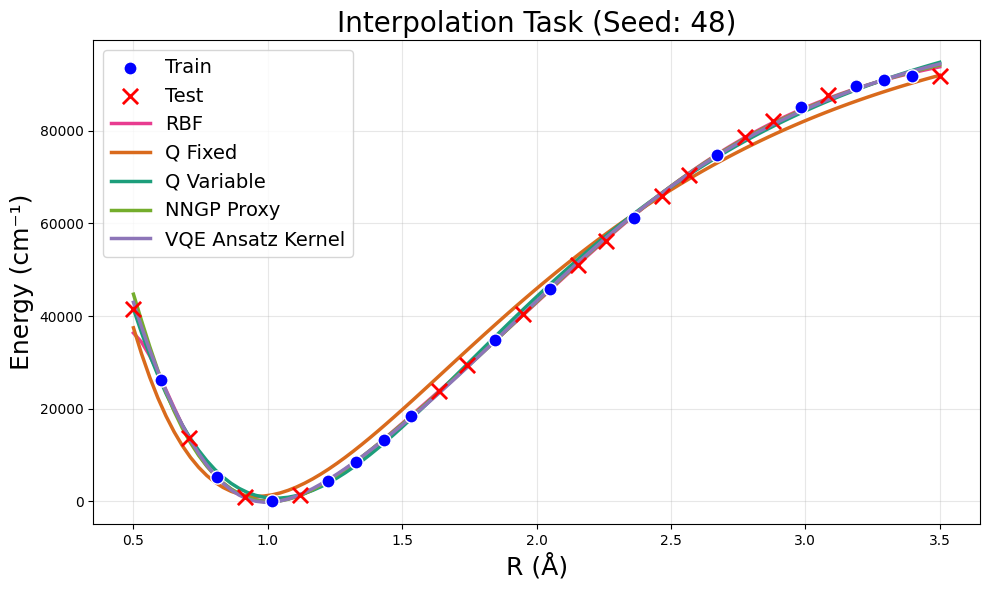

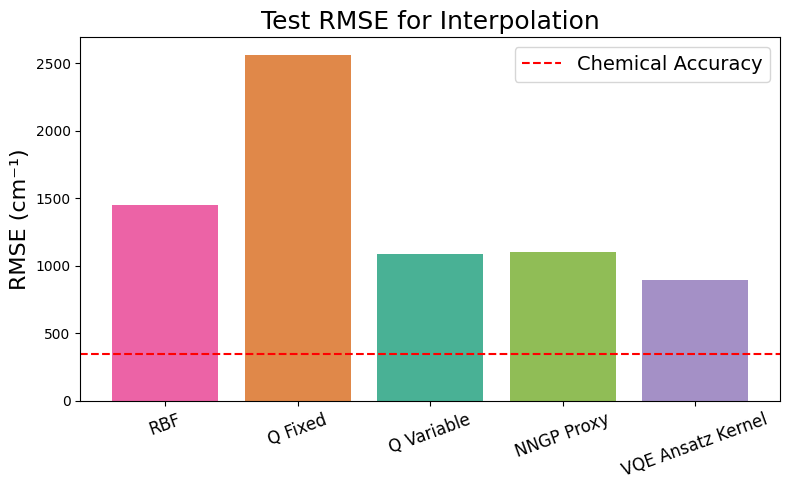

In [8]:
run_scenario("Interpolation", X, y, R)

2. Run Extrapolation


 SCENARIO: Extrapolation
Training DNN and optimizing VQE Proxy (This may take a minute)...
Results for Extrapolation:
 - RBF RMSE: 17547.61 cm-1
 - Q Fixed RMSE: 44266.46 cm-1
 - Q Variable RMSE: 14514.98 cm-1
 - NNGP Proxy RMSE: 9103.85 cm-1
 - VQE Ansatz Kernel RMSE: 1624.81 cm-1


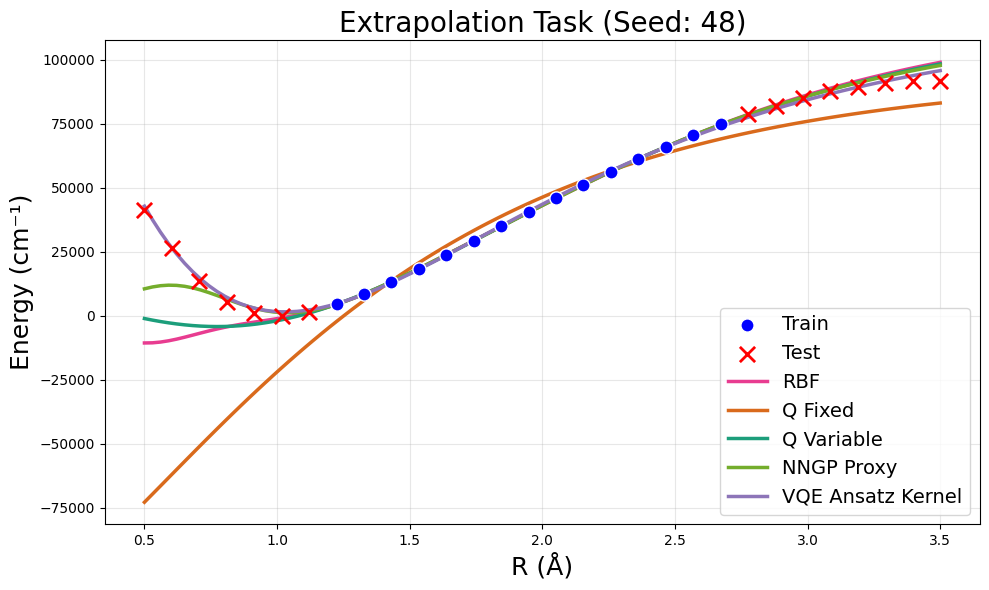

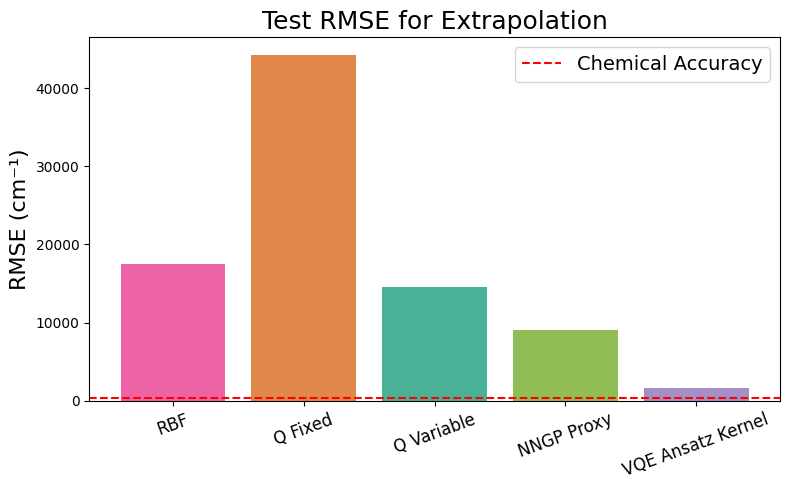

In [9]:
run_scenario("Extrapolation", X, y, R)